In [1]:
import json,os
import numpy as np
import pandas as pd

### Cargo datos

In [2]:
ligue2team2rank = json.load( open("ligue2team2rank.json", "r") )

In [3]:
matches = pd.read_csv("matches.csv")
matches.head(2)

,match,home,away,winner,score_home,score_away,label,liga
0,2500089,1646,1659,1659,1,2,"Burnley - AFC Bournemouth, 1 - 2",England
1,2500090,1628,1627,1628,2,0,"Crystal Palace - West Bromwich Albion, 2 - 0",England


In [4]:
metrics = pd.read_csv("metrics_crudas.csv")
metrics.head(2)

,match,team1,direct_play,counterattack,T_maintenance,T_build_up,T_zona_media,flow_rate,crossing,pressure_point,pressure_loss,shots,liga
0,2499719,1609,356.903763,38.475388,253.640098,448.696552,716.029417,20.868180,8,2086.0,50.528341,9,England
1,2499719,1631,151.371756,14.920580,116.388608,432.763020,211.277036,7.828017,3,1135.0,31.902325,0,England


<Axes: >

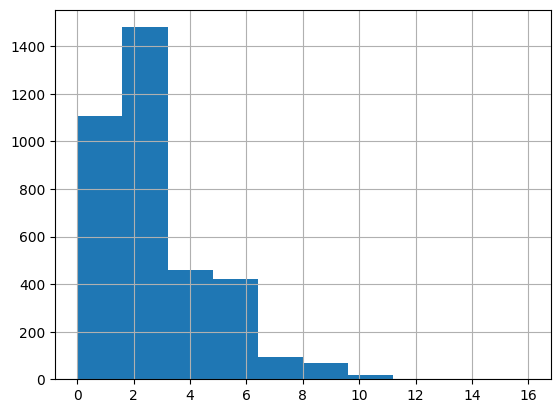

In [5]:
metrics["shots"].hist()

### Armo redes

Primero cruzo los datos por match

In [6]:
df0 = pd.merge(metrics, matches[['match', 'home', 'away', 'winner', 'score_home','score_away']], on='match', how='left')

df0.head(2)

,match,team1,direct_play,counterattack,T_maintenance,T_build_up,T_zona_media,flow_rate,crossing,pressure_point,pressure_loss,shots,liga,home,away,winner,score_home,score_away
0,2499719,1609,356.903763,38.475388,253.640098,448.696552,716.029417,20.868180,8,2086.0,50.528341,9,England,1609,1631,1609,4,3
1,2499719,1631,151.371756,14.920580,116.388608,432.763020,211.277036,7.828017,3,1135.0,31.902325,0,England,1609,1631,1609,4,3


In [9]:
metricas = ['direct_play','counterattack','T_build_up', 'T_zona_media','flow_rate','crossing','pressure_point',	'shots']

ligas = ['England','France','Germany','Italy','Spain']


for liga in ligas:

    print (liga)

    carpeta = f'{liga}'
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)


    team2rank = ligue2team2rank[liga]
    df = df0[ df0['liga']==liga ]


    for metrica in metricas:

        print (f"\t{metrica}")

        d={}
        d2={}

        def f(row):

            # tomo datos
            team1 = str(row.team1)
            nodo1 = team2rank[team1]

            if row.team1==row.home:
                team2=str(row.away)
            else:
                team2=str(row.home)

            nodo2 = team2rank[team2]

            w = row[metrica] 

            try:
                d[(nodo1,nodo2)]+=w
            except:
                d[(nodo1,nodo2)]=w

            try:
                d2[(team1,team2)].append(w)
            except:
                d2[(team1,team2)]=[w]
            

        df.agg( lambda x: f(x), axis=1 )


        # armo red
        Nmax = max(elemento for tupla in d for elemento in tupla)
        red = []

        for i in range(1,Nmax):

            for j in range(i+1, Nmax+1):

                #if metrica=="shots":
                fij = np.log(d[(j,i)]+1) - np.log( d[(i,j)]+1 )

                

                red.append( [i,j, fij] )



        #guardo data
        arx_out = f'{liga}/red_{metrica}.dat'

        np.savetxt(
            arx_out,               
            red,               
            fmt='%d,%d,%.4e',         
            delimiter=',', 
            header='n1,n2,fij',
            comments=''
        )



England
	direct_play
	counterattack
	T_build_up
	T_zona_media
	flow_rate
	crossing
	pressure_point
	shots
France
	direct_play
	counterattack
	T_build_up
	T_zona_media
	flow_rate
	crossing
	pressure_point
	shots
Germany
	direct_play
	counterattack
	T_build_up
	T_zona_media
	flow_rate
	crossing
	pressure_point
	shots
Italy
	direct_play
	counterattack
	T_build_up
	T_zona_media
	flow_rate
	crossing
	pressure_point
	shots
Spain
	direct_play
	counterattack
	T_build_up
	T_zona_media
	flow_rate
	crossing
	pressure_point
	shots
